# <span style="color: yellow;"> Análisis de Absentismo Laboral - RRHH (13-JUL-2026)</span>

---

### Preguntas de negocio

> Cómo influyen  en los niveles de absentismo los factores de:
- el consumo social de alcohol
- el consumo social de tabaco 
- los antecedentes disciplinarios

 > Cómo podríamos diseñar acciones preventivas y culturales para promover un entorno laboral más saludable y minimizar el impacto del absentismo?
 ---


### Antecedente:

En la semana anterior se desarrolló un modelo de regresión logística binaria, en el que la variable dependiente clasificaba a los empleados según pertenecieran o no al grupo de alto absentismo.
Resultados: sólo `Disciplinary Failure` salió estadísticamente significativa y con una alta probabilidad (aprox. 10%) de que, controlando el resto de variables, un miembro que sí tenga una falta disciplinaria forme parte del grupo de **absentismo alto**. Los resultados de las otras 2 variables de interés de esta semana fueron que el consumo social de alcohol y tabaco no mostraron una asociación estadísticamente significativa tras ajustar por el resto de variables:

- consumo social de **alcohol**: OR = 1,84 pero p-valor = 0,442*
- consumo social de **tabaco**: OR = 1,94 pero p-valor = 0,328*

*No se podía asegurar que los resultados no se debieran al azar en los registros de los empleados analizados.

---

### Pasos

1. La variable dependiente deja de ser binaria y pasa a representarse mediante 4 categorías ordinales (bajo, medio alto y severo).
2. Ajustar un modelo de regresión logística ordinal dado que la variable dependiente del análisis multivariante deja de ser binario (si el empleado forma parte de la categoría alto_absentismo o no).
3. Evaluar el efectos de las 4 variables sobre la probabilidad de pertenecer a uno los grupos de absentismo medida mediante odds ratios e intervalos de confianza.

### Metodología:

1. **Agregación por empleado.** Los registros del dataset son solicitudes de ausencia, no empleados individuales. Se agregan a nivel de persona (x empleados), para garantizar la independencia de las observaciones.
2. **Creación de las categorías de absentismo.**
3. **Test Variance Inflation Factor (VIF)** o análisis de colinealidad para asegurar la no relación fuerte de información entre las variables independientes (predictoras).
3. **Realización del modelo**
4. Interpretación.


## 1. Imports

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, date, time, timedelta
from getpass import getpass
from sqlalchemy import create_engine, inspect
from sqlalchemy.exc import SQLAlchemyError
import statsmodels.formula.api as smf
from statsmodels.miscmodels.ordinal_model import OrderedModel
from scipy.stats import chi2_contingency
import scipy.stats as stats
import statsmodels.api as sm
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from statsmodels.miscmodels.ordinal_model import OrderedModel
from statsmodels.discrete.discrete_model import MNLogit
from matplotlib.patches import FancyBboxPatch 
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.ticker import PercentFormatter, MaxNLocator

import os
from dotenv import load_dotenv

## 2. Carga de datos

In [3]:
if input("¿Desea conectarse a la base de datos (sino cargará desde CSV)? (s/n): ").lower() == "s":

    load_dotenv(dotenv_path=".env")
    MYSQL_PASSWORD = os.getenv("MYSQL_PASSWORD")
    MYSQL_HOST = os.getenv("MYSQL_HOST")
    MYSQL_PORT = os.getenv("MYSQL_PORT")
    MYSQL_USER = os.getenv("MYSQL_USER")
    MYSQL_DATABASE = os.getenv("MYSQL_DATABASE")

    try:
        engine = create_engine(
            f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}"
        )

        with engine.connect() :
            query = "SELECT * FROM RRHH_CLEAN_07072026;"
            df = pd.read_sql(query, engine)
        
        display("Datos de la base de datos cargados correctamente desde MySQL.")
        
    except SQLAlchemyError as error:
        display("No se pudo conectar o leer datos desde MySQL.")
        display(f"Detalle del error: {error}")
else:
    CSV_PATH = r'..\Data\DatasetClean_2026-07-13.csv'
    try:
        df = pd.read_csv(CSV_PATH)
        display("Datos cargados correctamente desde el archivo CSV.")

    except FileNotFoundError as error:
        raise FileNotFoundError(
            f"No se encontró el archivo CSV. Revisa la ruta: {CSV_PATH}"
    ) from error


'Datos cargados correctamente desde el archivo CSV.'

## 3. Preparación del dataset

### 3.1 Agregación por empleado

- Las horas de absentismo se agregan mediante **suma** (el total acumulado del período). 
- Se dividen en tres niveles usando el **percetil 33** 

In [4]:
# ============================================================
# 1. Una fila por empleado: sumar todas sus horas
# ============================================================

df_empleados = (
    df.groupby("ID_Employee", as_index=False)
    .agg(
        Total_Horas_Absentismo=("Absenteeism_Hours", "sum"),
        Social_Drinker=("Social_Drinker", "first"),
        Social_Smoker=("Social_Smoker", "first"),
        Disciplinary_Failure=("Disciplinary_Failure", "max")
    )
)

print("Empleados únicos:", df["ID_Employee"].nunique())
print("Filas de la tabla agrupada:", len(df_empleados))

# Ver el total de horas de cada empleado
df_empleados[
    ["ID_Employee", "Total_Horas_Absentismo"]
].sort_values(
    "Total_Horas_Absentismo",
    ascending=False
)

Empleados únicos: 386
Filas de la tabla agrupada: 386


,ID_Employee,Total_Horas_Absentismo
13,14,476
10,11,450
2,3,444
27,28,343
33,34,333
...,...,...
87,88,0
58,59,0
52,53,0
62,63,0


### Categorias de absentismo 

In [5]:
# ============================================================
# 1. Crear categorías según impacto operativo
# ============================================================

# Bajo:      0–8 horas
# Moderado:  9–24 horas
# Alto:      25–80 horas
# Severo:    más de 80 horas

df_empleados["Nivel_Absentismo_4"] = pd.cut(
    df_empleados["Total_Horas_Absentismo"],
    bins=[-np.inf, 8, 24, 80, np.inf],
    labels=[0, 1, 2, 3],
    right=True
).astype(int)

df_empleados["Nivel_Absentismo_4_Desc"] = (
    df_empleados["Nivel_Absentismo_4"].map({
        0: "Bajo",
        1: "Moderado",
        2: "Alto",
        3: "Severo"
    })
)

df_empleados["Nivel_Absentismo_4_Desc"] = pd.Categorical(
    df_empleados["Nivel_Absentismo_4_Desc"],
    categories=["Bajo", "Moderado", "Alto", "Severo"],
    ordered=True
)

# ============================================================
# 2. Comprobar distribución de las nuevas categorías
# ============================================================

resumen_categorias = (
    df_empleados
    .groupby("Nivel_Absentismo_4_Desc", observed=False)
    .agg(
        Empleados=("ID_Employee", "count"),
        Horas_Minimas=("Total_Horas_Absentismo", "min"),
        Horas_Maximas=("Total_Horas_Absentismo", "max"),
        Media_Horas=("Total_Horas_Absentismo", "mean"),
        Mediana_Horas=("Total_Horas_Absentismo", "median"),
        Total_Horas=("Total_Horas_Absentismo", "sum")
    )
    .reset_index()
)

print("Resumen de las categorías:")
display(resumen_categorias.round(2))

# ============================================================
# 3. Preparar datos para la regresión logística ordinal
# ============================================================

variables_modelo = [
    "Social_Drinker",
    "Social_Smoker",
    "Disciplinary_Failure"
]

df_modelo_ordinal_4 = df_empleados[
    [
        "ID_Employee",
        "Total_Horas_Absentismo",
        "Nivel_Absentismo_4",
        "Nivel_Absentismo_4_Desc",
        *variables_modelo
    ]
].dropna().copy()

df_modelo_ordinal_4["Nivel_Absentismo_4"] = (
    df_modelo_ordinal_4["Nivel_Absentismo_4"].astype(int)
)

df_modelo_ordinal_4[variables_modelo] = (
    df_modelo_ordinal_4[variables_modelo].astype(int)
)

# ============================================================
# 4. Revisar distribución por variable
# ============================================================

print("\nDistribución de los niveles:")

print(
    df_modelo_ordinal_4["Nivel_Absentismo_4_Desc"]
    .value_counts(sort=False)
)

for variable in variables_modelo:
    print(f"\nTabla: {variable}")

    display(
        pd.crosstab(
            df_modelo_ordinal_4[variable],
            df_modelo_ordinal_4["Nivel_Absentismo_4_Desc"],
            margins=True
        )
    )

# ============================================================
# 5. Regresión logística ordinal
# ============================================================

X = df_modelo_ordinal_4[variables_modelo].astype(float)
y = df_modelo_ordinal_4["Nivel_Absentismo_4"]

# OrderedModel no debe incluir una constante
modelo_ordinal_4 = OrderedModel(
    endog=y,
    exog=X,
    distr="logit"
)

resultado_ordinal_4 = modelo_ordinal_4.fit(
    method="bfgs",
    maxiter=1000,
    disp=False
)

print(resultado_ordinal_4.summary())

# ============================================================
# 6. Tabla de Odds Ratio y significación
# ============================================================

coeficientes = resultado_ordinal_4.params[variables_modelo]
p_values = resultado_ordinal_4.pvalues[variables_modelo]
intervalos = resultado_ordinal_4.conf_int().loc[variables_modelo]

resultados_modelo_4 = pd.DataFrame({
    "Variable": variables_modelo,
    "Coeficiente": coeficientes.values,
    "Odds_Ratio": np.exp(coeficientes.values),
    "IC_95_Inferior": np.exp(intervalos.iloc[:, 0].values),
    "IC_95_Superior": np.exp(intervalos.iloc[:, 1].values),
    "P_Value": p_values.values
})

resultados_modelo_4["Significativa"] = np.where(
    resultados_modelo_4["P_Value"] < 0.05,
    "Sí",
    "No"
)

resultados_modelo_4 = (
    resultados_modelo_4
    .sort_values("P_Value")
    .reset_index(drop=True)
)

display(resultados_modelo_4.round(4))

Resumen de las categorías:


,Nivel_Absentismo_4_Desc,Empleados,Horas_Minimas,Horas_Maximas,Media_Horas,Mediana_Horas,Total_Horas
0,Bajo,325,0,8,4.00,3.0,1299
1,Moderado,22,16,24,19.86,18.5,437
2,Alto,17,25,80,42.59,34.0,724
3,Severo,22,83,476,228.91,212.5,5036



Distribución de los niveles:
Nivel_Absentismo_4_Desc
Bajo        325
Moderado     22
Alto         17
Severo       22
Name: count, dtype: int64

Tabla: Social_Drinker


Nivel_Absentismo_4_Desc,Bajo,Moderado,Alto,Severo,All
Social_Drinker,,,,,
0,139,10,7,11,167
1,186,12,10,11,219
All,325,22,17,22,386



Tabla: Social_Smoker


Nivel_Absentismo_4_Desc,Bajo,Moderado,Alto,Severo,All
Social_Smoker,,,,,
0,301,20,13,20,354
1,24,2,4,2,32
All,325,22,17,22,386



Tabla: Disciplinary_Failure


Nivel_Absentismo_4_Desc,Bajo,Moderado,Alto,Severo,All
Disciplinary_Failure,,,,,
0,298,20,12,11,341
1,27,2,5,11,45
All,325,22,17,22,386


                             OrderedModel Results                             
Dep. Variable:     Nivel_Absentismo_4   Log-Likelihood:                -223.68
Model:                   OrderedModel   AIC:                             459.4
Method:            Maximum Likelihood   BIC:                             483.1
Date:                Wed, 15 Jul 2026                                         
Time:                        13:49:29                                         
No. Observations:                 386                                         
Df Residuals:                     380                                         
Df Model:                           3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Social_Drinker          -0.2284      0.289     -0.790      0.430      -0.795       0.339
Social_Smoker         

,Variable,Coeficiente,Odds_Ratio,IC_95_Inferior,IC_95_Superior,P_Value,Significativa
0,Disciplinary_Failure,1.7108,5.5334,2.7386,11.1804,0.0000,Sí
1,Social_Drinker,-0.2284,0.7958,0.4514,1.4030,0.4297,No
2,Social_Smoker,0.1059,1.1118,0.4460,2.7713,0.8202,No


## MODELO 

In [6]:
# ============================================================
# 1. Variables del modelo
# ============================================================

variables_modelo = [
    "Social_Drinker",
    "Social_Smoker",
    "Disciplinary_Failure"
]

columnas_modelo = [
    "ID_Employee",
    "Total_Horas_Absentismo",
    "Nivel_Absentismo_4",
    "Nivel_Absentismo_4_Desc",
    *variables_modelo
]

df_modelo_ordinal_4 = (
    df_empleados[columnas_modelo]
    .dropna()
    .copy()
)

# Variable dependiente:
# 0 = Bajo
# 1 = Moderado
# 2 = Alto
# 3 = Severo

df_modelo_ordinal_4["Nivel_Absentismo_4"] = (
    df_modelo_ordinal_4["Nivel_Absentismo_4"]
    .astype(int)
)

# Variables explicativas binarias: 0 / 1
df_modelo_ordinal_4[variables_modelo] = (
    df_modelo_ordinal_4[variables_modelo]
    .astype(int)
)

# ============================================================
# 2. Comprobar distribución
# ============================================================

orden_niveles = ["Bajo", "Moderado", "Alto", "Severo"]

print("Distribución de los niveles de absentismo:")

print(
    df_modelo_ordinal_4["Nivel_Absentismo_4_Desc"]
    .value_counts()
    .reindex(orden_niveles)
)

print("\nDistribución de las variables binarias:")

for variable in variables_modelo:
    print(f"\n{variable}")
    print(
        pd.crosstab(
            df_modelo_ordinal_4[variable],
            df_modelo_ordinal_4["Nivel_Absentismo_4_Desc"]
        ).reindex(columns=orden_niveles)
    )

# ============================================================
# 3. Preparar X e y
# ============================================================

X = df_modelo_ordinal_4[variables_modelo].astype(float)
y = df_modelo_ordinal_4["Nivel_Absentismo_4"]

# OrderedModel no debe incluir una constante
modelo_ordinal_4 = OrderedModel(
    endog=y,
    exog=X,
    distr="logit"
)

# ============================================================
# 4. Ajustar el modelo
# ============================================================

resultado_ordinal_4 = modelo_ordinal_4.fit(
    method="bfgs",
    maxiter=1000,
    disp=False
)

print(resultado_ordinal_4.summary())

# Comprobar convergencia
print(
    "\nConvergencia del modelo:",
    resultado_ordinal_4.mle_retvals.get("converged", "No disponible")
)

# ============================================================
# 5. Preparar resultados para el gráfico
# ============================================================

coeficientes = resultado_ordinal_4.params.loc[variables_modelo]
p_values = resultado_ordinal_4.pvalues.loc[variables_modelo]
intervalos = resultado_ordinal_4.conf_int().loc[variables_modelo]

resultados_modelo_4 = pd.DataFrame({
    "Variable": variables_modelo,
    "Coeficiente": coeficientes.values,
    "Odds_Ratio": np.exp(coeficientes.values),
    "IC_95_Inferior": np.exp(intervalos.iloc[:, 0].values),
    "IC_95_Superior": np.exp(intervalos.iloc[:, 1].values),
    "P_Value": p_values.values
})

# Nombres para el report
nombres_variables = {
    "Social_Drinker": "Consumo social de alcohol",
    "Social_Smoker": "Consumo social de tabaco",
    "Disciplinary_Failure": "Incidencia disciplinaria"
}

resultados_modelo_4["Variable_Desc"] = (
    resultados_modelo_4["Variable"]
    .map(nombres_variables)
)

resultados_modelo_4["Significativa"] = np.where(
    resultados_modelo_4["P_Value"] < 0.05,
    "Sí",
    "No"
)

resultados_modelo_4["Direccion"] = np.where(
    resultados_modelo_4["Odds_Ratio"] > 1,
    "Mayor probabilidad",
    "Menor probabilidad"
)

resultados_modelo_4 = (
    resultados_modelo_4
    .sort_values("Odds_Ratio", ascending=True)
    .reset_index(drop=True)
)

resultados_modelo_4.round(4)

Distribución de los niveles de absentismo:
Nivel_Absentismo_4_Desc
Bajo        325
Moderado     22
Alto         17
Severo       22
Name: count, dtype: int64

Distribución de las variables binarias:

Social_Drinker
Nivel_Absentismo_4_Desc  Bajo  Moderado  Alto  Severo
Social_Drinker                                       
0                         139        10     7      11
1                         186        12    10      11

Social_Smoker
Nivel_Absentismo_4_Desc  Bajo  Moderado  Alto  Severo
Social_Smoker                                        
0                         301        20    13      20
1                          24         2     4       2

Disciplinary_Failure
Nivel_Absentismo_4_Desc  Bajo  Moderado  Alto  Severo
Disciplinary_Failure                                 
0                         298        20    12      11
1                          27         2     5      11
                             OrderedModel Results                             
Dep. Variable:     Niv

,Variable,Coeficiente,Odds_Ratio,IC_95_Inferior,IC_95_Superior,P_Value,Variable_Desc,Significativa,Direccion
0,Social_Drinker,-0.2284,0.7958,0.4514,1.4030,0.4297,Consumo social de alcohol,No,Menor probabilidad
1,Social_Smoker,0.1059,1.1118,0.4460,2.7713,0.8202,Consumo social de tabaco,No,Mayor probabilidad
2,Disciplinary_Failure,1.7108,5.5334,2.7386,11.1804,0.0000,Incidencia disciplinaria,Sí,Mayor probabilidad


DISTRIBUCIÓN DE LOS REGISTROS EN 4 CATEGORÍAS MEDIANTE PERCENTILES: casi el 70% de tus empleados caen en la categoría "Bajo", mientras que "Moderado" y "Alto" apenas tienen 10 y 12 registros. En una muestra pequeña de 136 empleados, tener categorías con tan solo 10 registros debilita la potencia del modelo de regresión ordinal (provocando errores estándar grandes y p-valores inflados).

In [7]:
# ============================================================
# 1. Orden de las categorías
# ============================================================

orden_niveles = [
    "Bajo",
    "Moderado",
    "Alto",
    "Severo"
]

df_empleados["Nivel_Absentismo_4_Desc"] = pd.Categorical(
    df_empleados["Nivel_Absentismo_4_Desc"],
    categories=orden_niveles,
    ordered=True
)

# ============================================================
# 2. Convertir las horas acumuladas en días equivalentes
# ============================================================

horas_por_jornada = 8

df_empleados["Dias_Ausencia"] = (
    df_empleados["Total_Horas_Absentismo"] / horas_por_jornada
)

# ============================================================
# 3. Preparar tabla para los gráficos
# ============================================================

resumen_niveles_grafico = (
    df_empleados
    .groupby(
        "Nivel_Absentismo_4_Desc",
        observed=False
    )
    .agg(
        Numero_Empleados=("ID_Employee", "count"),
        Total_Horas=("Total_Horas_Absentismo", "sum"),
        Dias_Ausencia=("Dias_Ausencia", "sum"),
        Media_Horas_Empleado=("Total_Horas_Absentismo", "mean"),
        Mediana_Horas_Empleado=("Total_Horas_Absentismo", "median")
    )
    .reindex(orden_niveles)
    .reset_index()
)

resumen_niveles_grafico["Dias_Ausencia"] = (
    resumen_niveles_grafico["Dias_Ausencia"].round(1)
)

resumen_niveles_grafico["Media_Horas_Empleado"] = (
    resumen_niveles_grafico["Media_Horas_Empleado"].round(2)
)

resumen_niveles_grafico["Mediana_Horas_Empleado"] = (
    resumen_niveles_grafico["Mediana_Horas_Empleado"].round(2)
)

display(resumen_niveles_grafico)

,Nivel_Absentismo_4_Desc,Numero_Empleados,Total_Horas,Dias_Ausencia,Media_Horas_Empleado,Mediana_Horas_Empleado
0,Bajo,325,1299,162.4,4.00,3.0
1,Moderado,22,437,54.6,19.86,18.5
2,Alto,17,724,90.5,42.59,34.0
3,Severo,22,5036,629.5,228.91,212.5


### DISTRIBUCION DE AUSENCIAS POR NIVELES

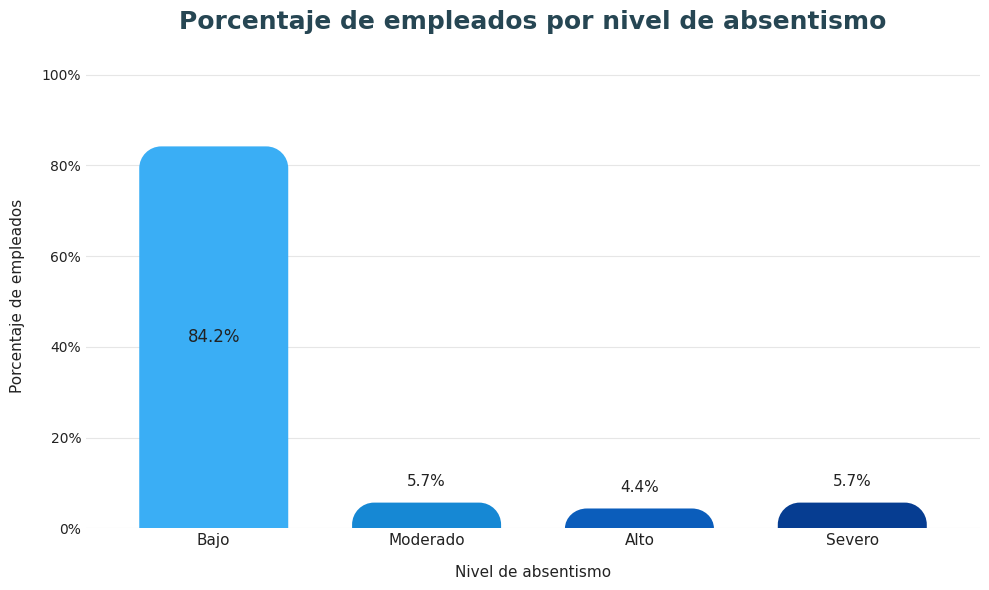

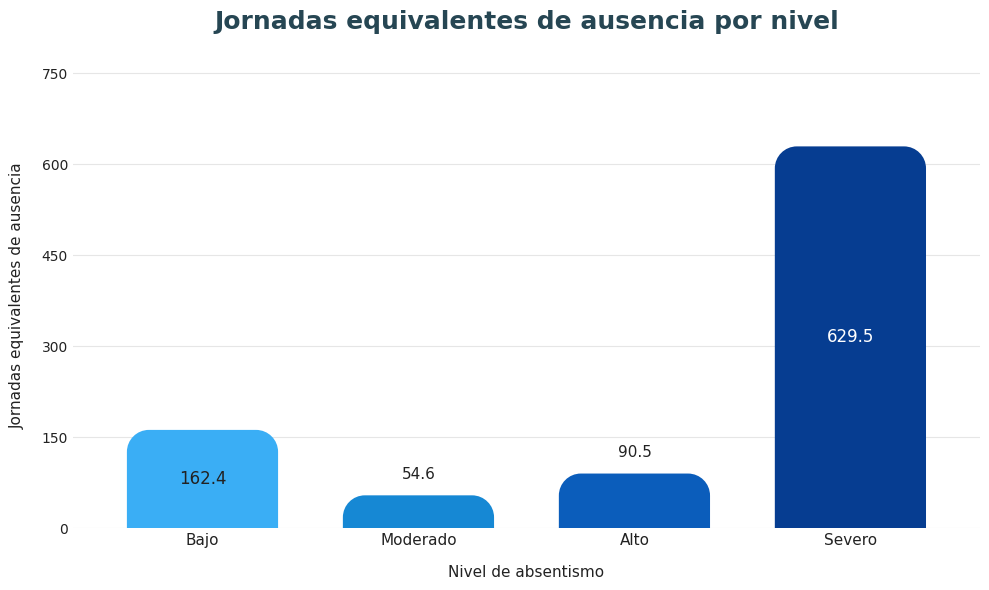

In [39]:
# ============================================================
# 1. Preparar datos
# ============================================================

niveles = (
    resumen_niveles_grafico["Nivel_Absentismo_4_Desc"]
    .astype(str)
    .tolist()
)

numero_empleados = (
    resumen_niveles_grafico["Numero_Empleados"]
    .astype(float)
    .to_numpy()
)

# Convertir número de empleados en porcentaje
porcentaje_empleados = (
    numero_empleados / numero_empleados.sum() * 100
)

dias_ausencia = (
    resumen_niveles_grafico["Dias_Ausencia"]
    .astype(float)
    .to_numpy()
)


# ============================================================
# 2. Estilo
# ============================================================

colores = [
    "#3AAEF5",  # Bajo
    "#1688D4",  # Moderado
    "#0B5DBB",  # Alto
    "#063D91"   # Severo
]

color_texto = "#222222"
color_titulo = "#264653"
color_grid = "#D9D9D9"
color_fondo = "#FFFFFF"


# ============================================================
# 3. Función para dibujar barras redondeadas solo arriba
# ============================================================

def crear_barra_superior_redondeada(
    ax,
    x_centro,
    altura,
    ancho,
    color,
    radio_pixeles=18
):
    """
    Crea una barra con:
    - esquinas inferiores cuadradas;
    - esquinas superiores redondeadas.
    """

    x0 = x_centro - ancho / 2
    x1 = x_centro + ancho / 2

    y0 = 0
    y1 = altura

    # Convertir el radio desde píxeles a unidades del gráfico
    punto_origen_display = ax.transData.transform((0, 0))
    punto_origen_data = ax.transData.inverted().transform(
        punto_origen_display
    )

    punto_x_data = ax.transData.inverted().transform(
        punto_origen_display + np.array([radio_pixeles, 0])
    )

    punto_y_data = ax.transData.inverted().transform(
        punto_origen_display + np.array([0, radio_pixeles])
    )

    radio_x = abs(
        punto_x_data[0] - punto_origen_data[0]
    )

    radio_y = abs(
        punto_y_data[1] - punto_origen_data[1]
    )

    # Evitar que el redondeado sea mayor que la barra
    radio_x = min(radio_x, ancho / 2)
    radio_y = min(radio_y, altura)

    # Constante para aproximar un cuarto de círculo
    kappa = 0.5522847498

    vertices = [
        # Base inferior izquierda
        (x0, y0),

        # Base inferior derecha
        (x1, y0),

        # Lateral derecho hasta el inicio de la curva
        (x1, y1 - radio_y),

        # Curva superior derecha
        (
            x1,
            y1 - radio_y + kappa * radio_y
        ),
        (
            x1 - radio_x + kappa * radio_x,
            y1
        ),
        (
            x1 - radio_x,
            y1
        ),

        # Parte superior
        (
            x0 + radio_x,
            y1
        ),

        # Curva superior izquierda
        (
            x0 + radio_x - kappa * radio_x,
            y1
        ),
        (
            x0,
            y1 - radio_y + kappa * radio_y
        ),
        (
            x0,
            y1 - radio_y
        ),

        # Lateral izquierdo hasta la base
        (x0, y0),

        # Cerrar figura
        (x0, y0)
    ]

    codigos = [
        Path.MOVETO,
        Path.LINETO,
        Path.LINETO,

        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,

        Path.LINETO,

        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,

        Path.LINETO,
        Path.CLOSEPOLY
    ]

    barra = PathPatch(
        Path(vertices, codigos),
        facecolor=color,
        edgecolor="none",
        linewidth=0,
        zorder=3
    )

    ax.add_patch(barra)


# ============================================================
# 4. Función general para crear cada gráfico por separado
# ============================================================

def crear_grafico_barras(
    categorias,
    valores,
    titulo,
    ylabel,
    colores,
    decimales=1,
    sufijo="",
    es_porcentaje=False,
    figsize=(10, 6),
    radio_pixeles=20
):
    valores = np.asarray(valores, dtype=float)

    fig, ax = plt.subplots(figsize=figsize)

    fig.patch.set_facecolor(color_fondo)
    ax.set_facecolor(color_fondo)

    x = np.arange(len(categorias))
    ancho = 0.70

    valor_maximo = (
        valores.max()
        if valores.max() > 0
        else 1
    )

    # Límites del gráfico
    ax.set_xlim(
        -0.60,
        len(categorias) - 0.40
    )

    ax.set_ylim(
        0,
        valor_maximo * 1.22
    )

    # Eje X
    ax.set_xticks(x)

    ax.set_xticklabels(
        categorias,
        fontsize=11,
        color=color_texto
    )

    # Título
    ax.set_title(
        titulo,
        fontsize=18,
        fontweight="bold",
        color=color_titulo,
        pad=24
    )

    ax.set_xlabel(
        "Nivel de absentismo",
        fontsize=11,
        color=color_texto,
        labelpad=12
    )

    ax.set_ylabel(
        ylabel,
        fontsize=11,
        color=color_texto,
        labelpad=12
    )

    # Formato del eje Y
    if es_porcentaje:

        ax.yaxis.set_major_formatter(
            PercentFormatter(
                xmax=100,
                decimals=0
            )
        )

    else:

        ax.yaxis.set_major_locator(
            MaxNLocator(nbins=7)
        )

    # Cuadrícula
    ax.grid(
        axis="y",
        linestyle="-",
        linewidth=0.8,
        alpha=0.65,
        color=color_grid,
        zorder=0
    )

    ax.set_axisbelow(True)

    # Quitar bordes
    for spine in [
        "top",
        "right",
        "left",
        "bottom"
    ]:
        ax.spines[spine].set_visible(False)

    ax.tick_params(
        axis="x",
        length=0,
        colors=color_texto
    )

    ax.tick_params(
        axis="y",
        length=0,
        colors=color_texto
    )

    # Ajustar primero el gráfico para calcular correctamente
    # el radio visual de las esquinas
    plt.tight_layout()
    fig.canvas.draw()

    # ========================================================
    # Crear barras
    # ========================================================

    for posicion, valor, color in zip(
        x,
        valores,
        colores
    ):

        crear_barra_superior_redondeada(
            ax=ax,
            x_centro=posicion,
            altura=valor,
            ancho=ancho,
            color=color,
            radio_pixeles=radio_pixeles
        )

        etiqueta = (
            f"{valor:.{decimales}f}{sufijo}"
        )

        # Etiqueta dentro de barras suficientemente altas
        if valor >= valor_maximo * 0.18:

            color_etiqueta = (
                "white"
                if color in colores[2:]
                else color_texto
            )

            ax.text(
                posicion,
                valor / 2,
                etiqueta,
                ha="center",
                va="center",
                fontsize=12,
                fontweight="medium",
                color=color_etiqueta,
                zorder=4
            )

        # Etiqueta encima cuando la barra sea pequeña
        else:

            ax.text(
                posicion,
                valor + valor_maximo * 0.035,
                etiqueta,
                ha="center",
                va="bottom",
                fontsize=11,
                fontweight="medium",
                color=color_texto,
                zorder=4
            )

    plt.show()


# ============================================================
# 5. Gráfico separado: porcentaje de empleados
# ============================================================

crear_grafico_barras(
    categorias=niveles,
    valores=porcentaje_empleados,
    titulo="Porcentaje de empleados por nivel de absentismo",
    ylabel="Porcentaje de empleados",
    colores=colores,
    decimales=1,
    sufijo="%",
    es_porcentaje=True,
    figsize=(10, 6),
    radio_pixeles=22
)


# ============================================================
# 6. Gráfico separado: jornadas de ausencia
# ============================================================

crear_grafico_barras(
    categorias=niveles,
    valores=dias_ausencia,
    titulo="Jornadas equivalentes de ausencia por nivel",
    ylabel="Jornadas equivalentes de ausencia",
    colores=colores,
    decimales=1,
    sufijo="",
    es_porcentaje=False,
    figsize=(10, 6),
    radio_pixeles=22
)

### DISTRIBUCION POR CADA VARIBALE POR NIVELES 


Distribución porcentual: Social_Smoker


Nivel_Absentismo_4_Desc,Bajo,Moderado,Alto,Severo
Social_Smoker,,,,
0,85.03,5.65,3.67,5.65
1,75.00,6.25,12.50,6.25


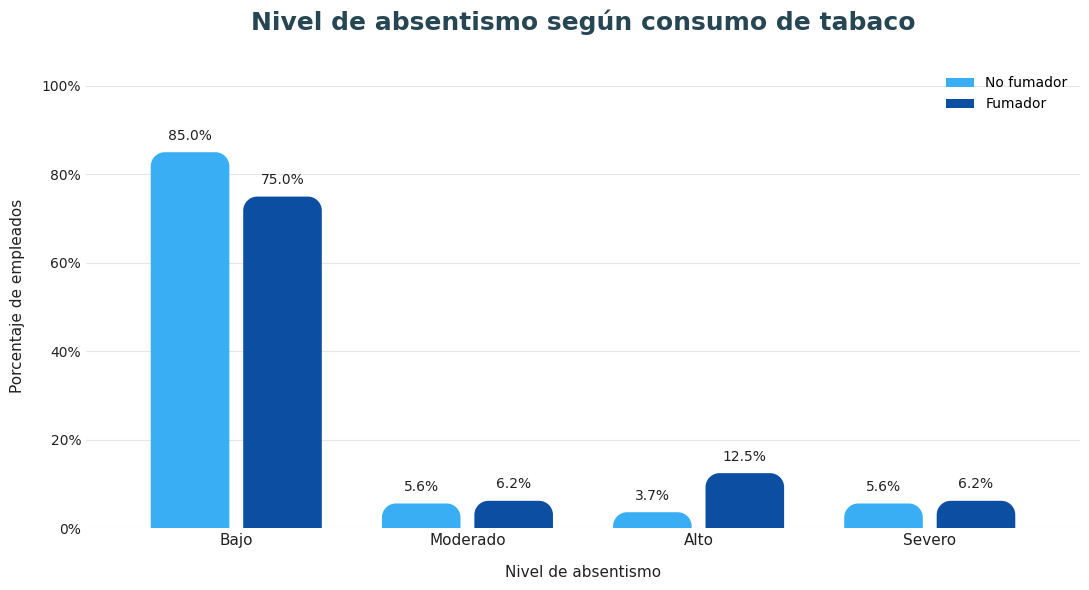


Distribución porcentual: Social_Drinker


Nivel_Absentismo_4_Desc,Bajo,Moderado,Alto,Severo
Social_Drinker,,,,
0,83.23,5.99,4.19,6.59
1,84.93,5.48,4.57,5.02


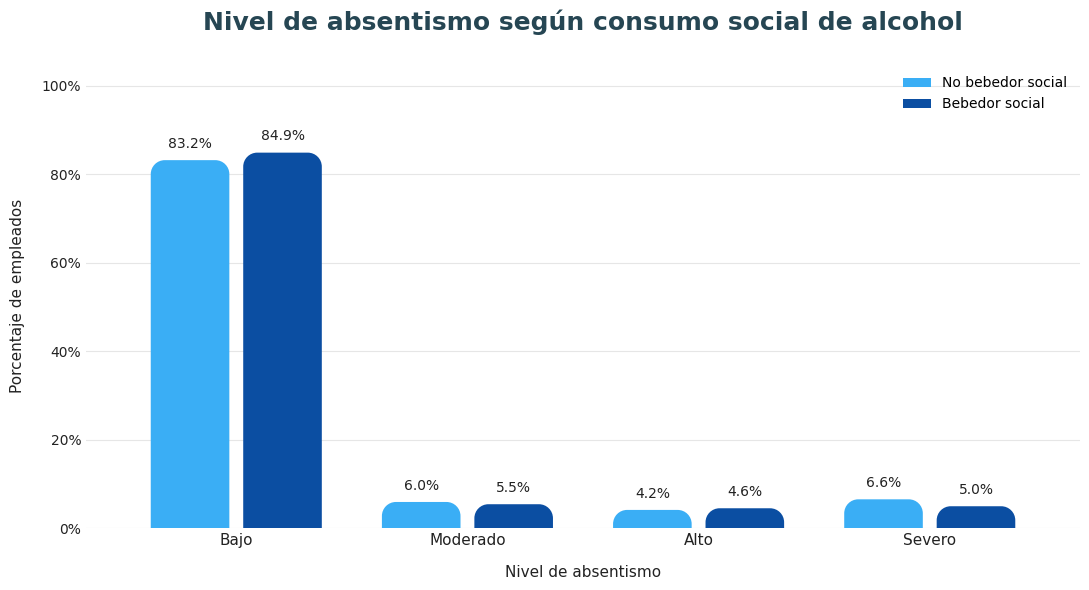


Distribución porcentual: Disciplinary_Failure


Nivel_Absentismo_4_Desc,Bajo,Moderado,Alto,Severo
Disciplinary_Failure,,,,
0,87.39,5.87,3.52,3.23
1,60.00,4.44,11.11,24.44


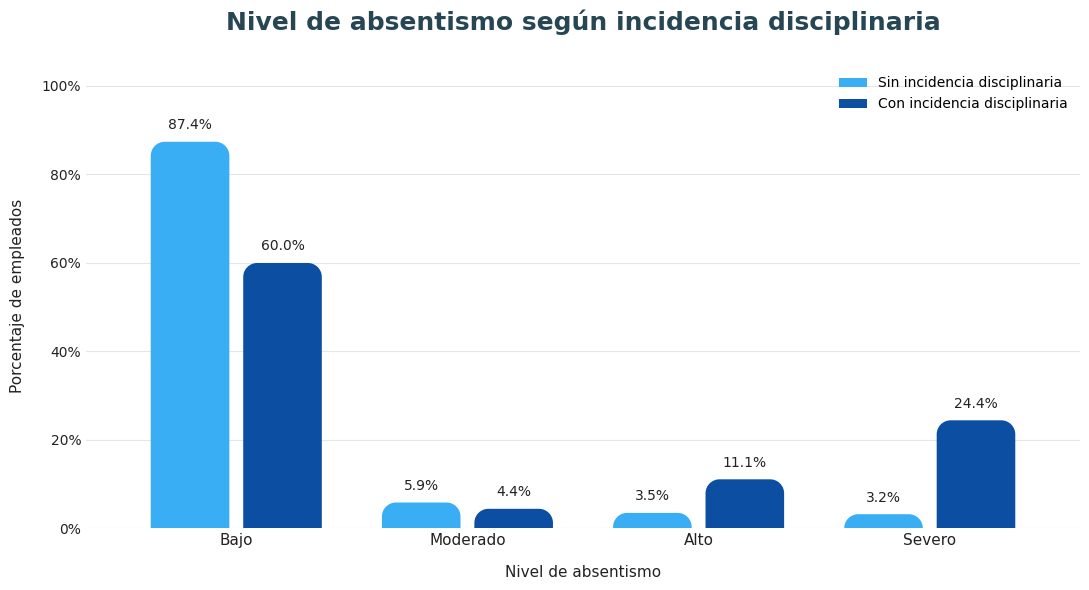

In [40]:
# ============================================================
# 1. Configuración
# ============================================================

orden_niveles = [
    "Bajo",
    "Moderado",
    "Alto",
    "Severo"
]

configuracion_variables = {
    "Social_Smoker": {
        "titulo": "Nivel de absentismo según consumo de tabaco",
        "grupo_0": "No fumador",
        "grupo_1": "Fumador"
    },

    "Social_Drinker": {
        "titulo": "Nivel de absentismo según consumo social de alcohol",
        "grupo_0": "No bebedor social",
        "grupo_1": "Bebedor social"
    },

    "Disciplinary_Failure": {
        "titulo": "Nivel de absentismo según incidencia disciplinaria",
        "grupo_0": "Sin incidencia disciplinaria",
        "grupo_1": "Con incidencia disciplinaria"
    }
}

color_grupo_0 = "#3AAEF5"
color_grupo_1 = "#0B4EA2"

color_texto = "#222222"
color_titulo = "#264653"
color_grid = "#D9D9D9"
color_fondo = "#FFFFFF"


# ============================================================
# 2. Barra con esquinas redondeadas solo arriba
# ============================================================

def crear_barra_superior_redondeada(
    ax,
    x_centro,
    altura,
    ancho,
    color,
    radio_pixeles=14
):
    x0 = x_centro - ancho / 2
    x1 = x_centro + ancho / 2

    y0 = 0
    y1 = altura

    origen_display = ax.transData.transform((0, 0))
    origen_data = ax.transData.inverted().transform(origen_display)

    punto_x = ax.transData.inverted().transform(
        origen_display + np.array([radio_pixeles, 0])
    )

    punto_y = ax.transData.inverted().transform(
        origen_display + np.array([0, radio_pixeles])
    )

    radio_x = abs(punto_x[0] - origen_data[0])
    radio_y = abs(punto_y[1] - origen_data[1])

    radio_x = min(radio_x, ancho / 2)
    radio_y = min(radio_y, altura)

    kappa = 0.5522847498

    vertices = [
        # Base inferior
        (x0, y0),
        (x1, y0),

        # Lateral derecho
        (x1, y1 - radio_y),

        # Esquina superior derecha
        (x1, y1 - radio_y + kappa * radio_y),
        (x1 - radio_x + kappa * radio_x, y1),
        (x1 - radio_x, y1),

        # Parte superior
        (x0 + radio_x, y1),

        # Esquina superior izquierda
        (x0 + radio_x - kappa * radio_x, y1),
        (x0, y1 - radio_y + kappa * radio_y),
        (x0, y1 - radio_y),

        # Lateral izquierdo
        (x0, y0),

        # Cerrar
        (x0, y0)
    ]

    codigos = [
        Path.MOVETO,
        Path.LINETO,
        Path.LINETO,

        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,

        Path.LINETO,

        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,

        Path.LINETO,
        Path.CLOSEPOLY
    ]

    barra = PathPatch(
        Path(vertices, codigos),
        facecolor=color,
        edgecolor="none",
        linewidth=0,
        zorder=3
    )

    ax.add_patch(barra)


# ============================================================
# 3. Función para preparar los porcentajes
# ============================================================

def calcular_porcentajes_por_perfil(df, variable):
    """
    Calcula la distribución porcentual de los niveles de
    absentismo dentro de los grupos 0 y 1 de cada variable.
    """

    tabla = pd.crosstab(
        index=df[variable],
        columns=df["Nivel_Absentismo_4_Desc"],
        normalize="index"
    ) * 100

    tabla = tabla.reindex(
        index=[0, 1],
        columns=orden_niveles,
        fill_value=0
    )

    return tabla


# ============================================================
# 4. Función para crear cada gráfico
# ============================================================

def crear_grafico_comparativo(
    tabla,
    titulo,
    etiqueta_grupo_0,
    etiqueta_grupo_1,
    figsize=(11, 6)
):
    valores_grupo_0 = tabla.loc[0].to_numpy(dtype=float)
    valores_grupo_1 = tabla.loc[1].to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=figsize)

    fig.patch.set_facecolor(color_fondo)
    ax.set_facecolor(color_fondo)

    x = np.arange(len(orden_niveles))

    ancho = 0.34
    separacion = 0.20

    posiciones_grupo_0 = x - separacion
    posiciones_grupo_1 = x + separacion

    valor_maximo = max(
        valores_grupo_0.max(),
        valores_grupo_1.max(),
        1
    )

    ax.set_xlim(-0.65, len(orden_niveles) - 0.35)
    ax.set_ylim(0, min(105, valor_maximo * 1.25))

    ax.set_xticks(x)

    ax.set_xticklabels(
        orden_niveles,
        fontsize=11,
        color=color_texto
    )

    ax.set_title(
        titulo,
        fontsize=18,
        fontweight="bold",
        color=color_titulo,
        pad=24
    )

    ax.set_xlabel(
        "Nivel de absentismo",
        fontsize=11,
        color=color_texto,
        labelpad=12
    )

    ax.set_ylabel(
        "Porcentaje de empleados",
        fontsize=11,
        color=color_texto,
        labelpad=12
    )

    ax.yaxis.set_major_formatter(
        PercentFormatter(xmax=100, decimals=0)
    )

    ax.grid(
        axis="y",
        linestyle="-",
        linewidth=0.8,
        alpha=0.65,
        color=color_grid,
        zorder=0
    )

    ax.set_axisbelow(True)

    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)

    ax.tick_params(
        axis="x",
        length=0,
        colors=color_texto
    )

    ax.tick_params(
        axis="y",
        length=0,
        colors=color_texto
    )

    # Necesario para calcular bien el redondeado
    plt.tight_layout()
    fig.canvas.draw()

    # ========================================================
    # Barras del grupo 0
    # ========================================================

    for posicion, valor in zip(
        posiciones_grupo_0,
        valores_grupo_0
    ):
        crear_barra_superior_redondeada(
            ax=ax,
            x_centro=posicion,
            altura=valor,
            ancho=ancho,
            color=color_grupo_0,
            radio_pixeles=14
        )

        ax.text(
            posicion,
            valor + valor_maximo * 0.025,
            f"{valor:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            color=color_texto,
            zorder=4
        )

    # ========================================================
    # Barras del grupo 1
    # ========================================================

    for posicion, valor in zip(
        posiciones_grupo_1,
        valores_grupo_1
    ):
        crear_barra_superior_redondeada(
            ax=ax,
            x_centro=posicion,
            altura=valor,
            ancho=ancho,
            color=color_grupo_1,
            radio_pixeles=14
        )

        ax.text(
            posicion,
            valor + valor_maximo * 0.025,
            f"{valor:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            color=color_texto,
            zorder=4
        )

    # Leyenda manual
    leyenda_grupo_0 = PathPatch(
        Path.unit_rectangle(),
        facecolor=color_grupo_0,
        edgecolor="none",
        label=etiqueta_grupo_0
    )

    leyenda_grupo_1 = PathPatch(
        Path.unit_rectangle(),
        facecolor=color_grupo_1,
        edgecolor="none",
        label=etiqueta_grupo_1
    )

    ax.legend(
        handles=[leyenda_grupo_0, leyenda_grupo_1],
        frameon=False,
        loc="upper right",
        fontsize=10
    )

    plt.show()


# ============================================================
# 5. Crear los tres gráficos separados
# ============================================================

for variable, configuracion in configuracion_variables.items():

    tabla_porcentajes = calcular_porcentajes_por_perfil(
        df=df_empleados,
        variable=variable
    )

    print(f"\nDistribución porcentual: {variable}")
    display(tabla_porcentajes.round(2))

    crear_grafico_comparativo(
        tabla=tabla_porcentajes,
        titulo=configuracion["titulo"],
        etiqueta_grupo_0=configuracion["grupo_0"],
        etiqueta_grupo_1=configuracion["grupo_1"],
        figsize=(11, 6)
    )

### GRAFICO DE RESULTADOS DE LOS FACTORES ASOCIADOS A NIVLES SEVEROS DE ABSENTISMO 

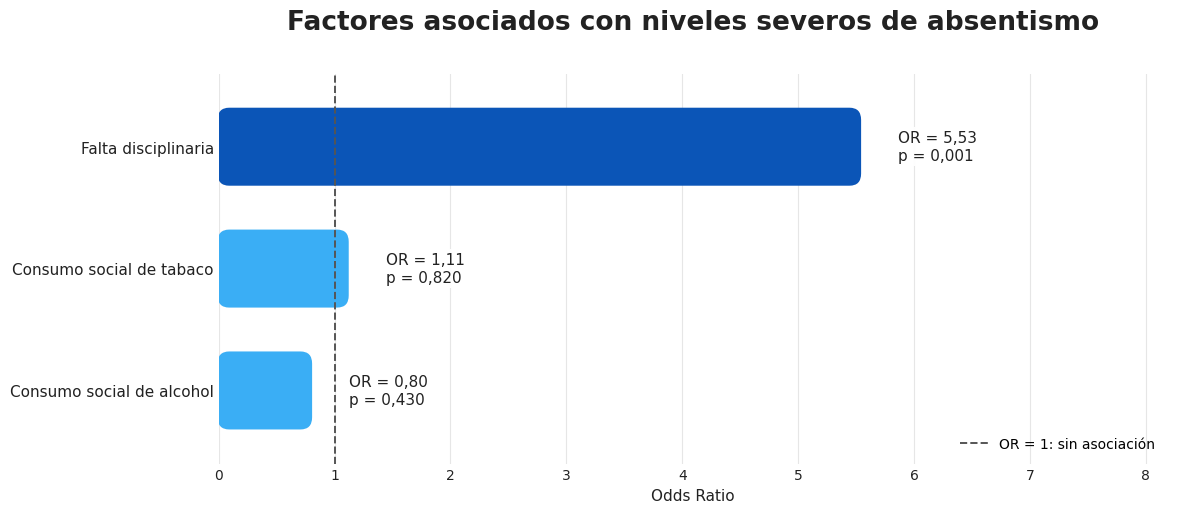

In [30]:
# ============================================================
# 1. Preparar resultados del modelo
# ============================================================

grafico_modelo = resultados_modelo_4.copy()

nombres_variables = {
    "Social_Drinker": "Consumo social de alcohol",
    "Social_Smoker": "Consumo social de tabaco",
    "Disciplinary_Failure": "Falta disciplinaria"
}

grafico_modelo["Variable_Desc"] = (
    grafico_modelo["Variable"].map(nombres_variables)
)

# Ordenar por Odds Ratio
grafico_modelo = (
    grafico_modelo
    .sort_values("Odds_Ratio", ascending=True)
    .reset_index(drop=True)
)

# ============================================================
# 2. Colores
# ============================================================

color_significativo = "#0B55B7"
color_no_significativo = "#3AAEF5"
color_texto = "#222222"
color_secundario = "#6C757D"
color_grid = "#D9D9D9"
color_fondo = "#FFFFFF"

# Azul oscuro si p < 0,05
colores = [
    color_significativo
    if p_value < 0.05
    else color_no_significativo
    for p_value in grafico_modelo["P_Value"]
]

# ============================================================
# 3. Crear gráfico
# ============================================================

fig, ax = plt.subplots(figsize=(13, 6))

fig.patch.set_facecolor(color_fondo)
ax.set_facecolor(color_fondo)

y = np.arange(len(grafico_modelo))
alto_barra = 0.62

max_or = grafico_modelo["Odds_Ratio"].max()

# Separación entre el final de cada barra y su etiqueta
separacion_etiqueta = max_or * 0.06

# Margen derecho para que no se corten las etiquetas
limite_x = max_or * 1.48

ax.set_xlim(0, limite_x)
ax.set_ylim(-0.6, len(grafico_modelo) - 0.4)

# ============================================================
# 4. Barras y etiquetas
# ============================================================

for posicion, (_, fila) in enumerate(grafico_modelo.iterrows()):

    # Barra redondeada
    barra = FancyBboxPatch(
        (0, posicion - alto_barra / 2),
        fila["Odds_Ratio"],
        alto_barra,
        boxstyle="round,pad=0.01,rounding_size=0.10",
        linewidth=0,
        facecolor=colores[posicion],
        transform=ax.transData,
        clip_on=True
    )

    ax.add_patch(barra)

    # Texto del p-value
    p_texto = (
        "p = 0,001"
        if fila["P_Value"] < 0.001
        else f"p = {fila['P_Value']:.3f}".replace(".", ",")
    )

    # Texto del Odds Ratio
    or_texto = (
        f"OR = {fila['Odds_Ratio']:.2f}"
        .replace(".", ",")
    )

    # Posición al lado de su propia barra
    x_etiqueta = fila["Odds_Ratio"] + separacion_etiqueta

    ax.text(
        x_etiqueta,
        posicion,
        f"{or_texto}\n{p_texto}",
        ha="left",
        va="center",
        fontsize=11,
        color=color_texto,
        linespacing=1.30,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.95,
            pad=2
        )
    )

# ============================================================
# 5. Línea de referencia OR = 1
# ============================================================

ax.axvline(
    1,
    color="#555555",
    linestyle="--",
    linewidth=1.4,
    label="OR = 1: sin asociación"
)

# ============================================================
# 6. Formato del gráfico
# ============================================================

ax.set_yticks(y)

ax.set_yticklabels(
    grafico_modelo["Variable_Desc"],
    fontsize=11,
    color=color_texto
)

ax.set_title(
    "Factores asociados con niveles severos de absentismo",
    fontsize=19,
    fontweight="bold",
    color=color_texto,
    pad=32
)


ax.set_xlabel(
    "Odds Ratio",
    fontsize=11,
    color=color_texto
)

ax.grid(
    axis="x",
    linestyle="-",
    linewidth=0.8,
    alpha=0.65,
    color=color_grid
)

ax.set_axisbelow(True)

# Quitar bordes
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

ax.tick_params(
    axis="x",
    length=0,
    colors=color_texto
)

ax.tick_params(
    axis="y",
    length=0
)

ax.legend(
    frameon=False,
    loc="lower right",
    fontsize=10
)

plt.subplots_adjust(
    top=0.80,
    bottom=0.15,
    left=0.24,
    right=0.97
)

plt.show()

In [9]:
df_modelo_ordinal_4.describe()

,ID_Employee,Total_Horas_Absentismo,Nivel_Absentismo_4,Social_Drinker,Social_Smoker,Disciplinary_Failure
count,386.000000,386.000000,386.000000,386.000000,386.000000,386.000000
mean,193.500000,19.419689,0.316062,0.567358,0.082902,0.116580
std,111.572846,59.963322,0.804921,0.496085,0.276091,0.321336
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,97.250000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,193.500000,4.000000,0.000000,1.000000,0.000000,0.000000
75%,289.750000,8.000000,0.000000,1.000000,0.000000,0.000000
max,386.000000,476.000000,3.000000,1.000000,1.000000,1.000000


## Análisis de colinealidad (VIF)
Responde a: "¿Cuánto se está multiplicando (inflando) el margen de error de mi variable por culpa de que otras variables le están robando o duplicando la información?". El VIF es un termómetro que mide qué tan "clones" son las variables predictoras.
Como interpretar VIF  
VIF= 1 -> Independencia Total  
VIF = 1-5 -> Moderado/aceptable  
VIF ->5 Multicolinealidad Severa.  

In [10]:
df_filtrado = df_modelo_ordinal_4[['Social_Smoker', 'Social_Drinker', 'Disciplinary_Failure']].dropna()

# Convertir las variables categóricas a números (0/1). Se usa drop_first=True para evitar la multicolinealidad perfecta
X_numerico = pd.get_dummies(df_filtrado, drop_first=True, dtype=int)

# Añadimos la constante (intercepto)
X = add_constant(X_numerico)

# # Calculo del VIF para cada columna
vif_df = pd.DataFrame()
vif_df["Variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]


print("Resultados del VIF")
print(vif_df[vif_df["Variable"] != 'const'])

Resultados del VIF
               Variable       VIF
1         Social_Smoker  1.041171
2        Social_Drinker  1.014146
3  Disciplinary_Failure  1.045747


## Test de BRANT
Contexto: La regresión logística ordinal tiene una regla muy estricta (el supuesto de odds proporcionales): asume que el empujón tiene exactamente la misma fuerza en todos los peldaños de la escalera. El empujón para pasar de Bajo a Medio tiene que ser igual de fuerte, que para pasar de Medio a Alto.   
El test de BRANT mide la fuerza del empujón en cada peldaño (categoría de absentismo) por separado y los compara.  
Si los empujones son parecidos (Líneas Paralelas - p > 0.05): Ok, el efecto es constante en toda la escalera de categorías. Se cumple el supuesto. El modelo ordinal es válido para su uso

In [11]:
# 1. Filtrar las 4 variables
columnas = ['Social_Smoker', 'Social_Drinker', 'Disciplinary_Failure', 'Nivel_Absentismo_4_Desc']
df_limpio = df_modelo_ordinal_4[columnas].dropna()

# 2. PREPARAR VARIABLES: Convertir las var. X a números (0 y 1) y la Y a categorías (0, 1, 2, 3)
X = pd.get_dummies(df_limpio[['Social_Smoker', 'Social_Drinker', 'Disciplinary_Failure']], drop_first=True, dtype=float)
y = pd.Categorical(df_limpio['Nivel_Absentismo_4_Desc'], categories=['Bajo', 'Medio', 'Alto', 'Severo'], ordered=True).codes

# 3. ENTRENAR MODELOS modelo Ordinal y el Multinomial
modelo_ordinal = OrderedModel(y, X, distr='logit').fit(method='bfgs', disp=False)

X_con_constante = X.assign(const=1.0) # El multinomial necesita una columna constante obligatoria
modelo_multinomial = MNLogit(y, X_con_constante).fit(disp=False)

# 4. COMPARAR la diferencia matemática entre ambos modelos
chi2_stat = 2 * (modelo_multinomial.llf - modelo_ordinal.llf)
grados_libertad = modelo_multinomial.df_model - modelo_ordinal.df_model
p_valor = 1 - stats.chi2.cdf(chi2_stat, grados_libertad)


print(f"Resultado del Test (p-valor): {p_valor:.4f}")

Resultado del Test (p-valor): 0.2158


El modelo ordinal es válido para su uso

## JUSTIFICACIÓN ESTADÍSTICA DEL USO DEL MODELO DE REGRESIÓN LOGÍSTICA ORDINAL

1) **¿Por qué esta técnica de análisis?** Técnica de Regresión logística ordinal

    Objetivo del análisis: estudiar cómo influyen en los niveles de absentismo los atributos de:
-consumo social de alcohol,
-consumo social de tabaco
-los antecedentes de falta disciplinaria. 

La variable dependiente se convierte a 4 niveles de absentismo por empleado con relación ordinal (bajo, medio, alto y severo), por lo que la regresión logística ordinal es la técnica más adecuada. 
- El modelo aprovecha el orden entre las categorías y nos permitirá evaluar el efecto simultáneo de varias variables personales (2) y laborales (1) controlando el efecto del resto.
- Se descarta la regresión lineal porque la variable de absentismo es continua y nos diría como influyen las variables a las horas exactas de absentismo, no a los niveles de absentismo (pregunta de negocio de este sprint). No obstante, también podría usarse como modelo testeado 2 para dar más fuerza si se encuentran asociaciones en alguna dirección.
L
2) **¿Qué supuestos tiene la técnica y cómo se verificó que los datos cumplían?**
Supuestos:
- Variable dependiente ordinal (orden natural entre las categorías, de más a menos / menos a más).
- Cada observación es de un individuo independiente gracias a la agrupación de solicitudes de ausencia por empleado.
- Ausencia de multicolinealidad. Las variables explicativas no tienen que estar correlacionadas fuertemente. Se comprueba con Variance Inflation Factor.
- Tamaño de los datos suficiente: Se tendrán que definir grupos equilibrados con suficientes registros en cada categoría.
- Para validar la proporcionalidad de odds test de BRANT.

3) **¿Qué limitaciones tiene esta técnica y cómo podrían afectar a tus conclusiones?**
- Muestra limitada: 136 trabajadores. Puede perder información entre las asociaciones pequeñas.
- Acertar en la mejor definición de las categorías proviniendo de una numérica continua. Parece que la bibliografía indica que la definición depende de cada empresa y no hay un estándar generalizar en el sector o en general.
- El modelo encontrará asociaciones, pero no relaciones de causa de cara a definir medidas y propuestas internas.